# 03 · SVD ve PCA'yı Sıfırdan Kurma
**Linear Algebra Lab** — Bu Serinin En Görsel ve En Kapsamlı Notebook'u

---
> **Bu notebook'ta ne öğreneceğiz?**  
> SVD ilk bakışta ürkütücü görünen ama aslında son derece sezgisel bir fikir. Tek bir cümleyle özetlersek: **SVD,
> "karmaşık bir şeyi, en önemli parçalarına ayırıp, gereksiz kısımları atma" işlemidir.**
> 02'de özdeğer/özvektörü sadece KARE matrisler için öğrendik — SVD, bu fikri HERHANGİ
> boyuttaki (kare olmayan da dahil) bir matriseye genelleştiriyor. Bunu öğrenince hem
> PCA'yı kütüphanesiz kurabileceksin hem de bir görüntüyü nasıl "sıkıştırdığını" göreceksin.

**Önkoşul:** Vektör/Matris Temelleri (01), Özdeğer/Özvektör (02)  
**Veri:**  
- `WA_Fn-UseC_-HR-Employee-Attrition.csv` — 1470 çalışan, 26 sayısal özellik (IBM HR Analytics)  
- `skimage.data` — yerleşik test görüntüsü (indirme gerekmez)  
**Araçlar:** Python (`numpy.linalg`, `scikit-learn`, `scikit-image`, `matplotlib`)

---
## 1 · Önce Çok Basit Bir Benzetmeyle Başlayalım

Diyelim ki arkadaşına bir insanı tarif ediyorsun. Söyleyebileceğin YÜZLERCE detay var
(boyu, kilosu, saç rengi, ayakkabı numarası, sevdiği yemek...). Ama pratikte sen bunu
yapmıyorsun — birkaç tane **en önemli** özelliği söylüyorsun ("uzun boylu, esmer, gözlüklü")
ve arkadaşın o kişiyi zihninde yeterince iyi canlandırıyor. Geri kalan yüzlerce detayı
söylemesen de olur, çünkü onlar "ek bilgi" — resmi değiştirmiyorlar, sadece detaylandırıyorlar.

**SVD ve PCA, tam olarak bunu SAYISAL VERİDE yapan matematiksel araçlar.** Elinde 26
sütunlu bir veri (bu notebook'taki HR verisi gibi) olduğunda, SVD sana "bu 26 sütunun
içindeki EN ÖNEMLİ birkaç yönü" buluyor — geri kalanını atarsan bile verinin "ruhunu"
kaybetmiyorsun.

---
## 2 · SVD Formülü: $A = U\Sigma V^T$ — Her Harfi Tek Tek Açıklayalım

Bu formül ilk bakışta korkutucu görünüyor ama parça parça çok basit. Herhangi bir $m\times n$
matris $A$ (kare olması bile GEREKMİYOR — bu SVD'yi 02'deki eigenvalue'den daha güçlü yapan
şey), ÜÇ matrisin çarpımına ayrıştırılabilir:

$$A = U \cdot \Sigma \cdot V^T$$

- **$U$** ($m\times m$): Sol tekil vektörler. Bunları "çıktı uzayının doğal eksenleri" gibi düşün.
- **$\Sigma$** ($m\times n$, köşegen): **Tekil değerler (singular values)**. Bunlar HER ZAMAN
  pozitif sayılardır ve BÜYÜKTEN KÜÇÜĞE sıralıdır — "bu ekseninin ne kadar ÖNEMLİ olduğunu"
  gösteren sayılar (Bölüm 6'da detaylandıracağız).
- **$V^T$** ($n\times n$): Sağ tekil vektörler. "Girdi uzayının doğal eksenleri" gibi düşün.

**En basit tarif:** SVD, bir dönüşümü 3 basit adıma ayırıyor — **dön (V^T) → basitçe
ölçekle (Σ) → tekrar dön (U)**. 01'de gördüğün rotasyon+ölçekleme+shear'in birleşimi olan
KARMAŞIK herhangi bir dönüşüm, aslında hep "dön-ölçekle-dön" olarak yeniden yazılabilir —
SVD bunu senin için buluyor.

---
## 3 · SVD, Özdeğer/Özvektörün "Büyütülmüş" Hali

02'de öğrendiğin eigenvalue/eigenvector SADECE **kare** matrisler için çalışıyordu
($A\vec{v}=\lambda\vec{v}$ denklemi, $A$ kare olmak zorunda çünkü $\vec{v}$ ile aynı boyutta
bir sonuç üretmesi gerekiyor). Ama gerçek dünyada veri setleri nadiren kare olur — HR
verimizde 1470 satır, 26 sütun var, bu KARE değil!

**SVD'nin büyük numarası:** $A$ kare olmasa bile, $A^TA$ HER ZAMAN karedir (ve simetriktir —
02 Bölüm 5'teki özel garantiler devreye giriyor!). SVD, aslında $A^TA$'nın özdeğer/
özvektörlerini kullanarak hesaplanıyor. Yani SVD, "02'de öğrendiğin şeyi, kare olmayan
matrislere de uygulayabilmek için bulunmuş zekice bir yöntem" olarak düşünebilirsin.

---
## 4 · PCA Nedir? Adım Adım, Hiç Atlamadan

PCA (Principal Component Analysis / Temel Bileşen Analizi), verideki en önemli "yönleri"
bulup, veriyi o yönlere göre yeniden ifade etme işlemidir. İşte TAM OLARAK yapılan 4 adım
— hiçbirini atlamadan:

**Adım 1 — Veriyi Merkezle:** Her sütunun kendi ortalamasını sütundan çıkar (böylece her
sütunun ortalaması 0 olur). Neden? Çünkü PCA "veri nereye doğru YAYILIYOR" sorusuyla
ilgileniyor, "veri nerede DURUYOR" ile değil — merkezlemek, orijini verinin "merkezine"
taşıyıp sadece yayılıma odaklanmamızı sağlıyor.

**Adım 2 — Kovaryans Matrisini Hesapla:** `probability-lab` 04b'deki formülü hatırla —
her sütun çiftinin birlikte ne kadar değiştiğini gösteren bir tablo.

**Adım 3 — Kovaryans Matrisinin Özdeğer/Özvektörlerini Bul:** 02'de öğrendiğimiz işlem!
En büyük özdeğere sahip özvektör = **birinci temel bileşen (PC1)** = verinin EN ÇOK
yayıldığı yön.

**Adım 4 — Veriyi Yeni Eksenlere Projekte Et:** Orijinal veriyi, bulduğumuz özvektörler
(yeni eksenler) üzerine "düşür" (01 Bölüm 3'teki projeksiyon formülü) — bu, verinin YENİ
koordinatları.

**SVD ile kısayol:** Bu 4 adımı tek tek yapmak yerine, merkezlenmiş veriye DOĞRUDAN SVD
uygularsan, aynı sonuca çok daha hızlı ve sayısal olarak daha kararlı bir şekilde ulaşırsın
— Python bölümünde İKİ yöntemi de yapıp sonuçların birebir örtüştüğünü göreceğiz.

---
## 5 · Boyut İndirgeme: "Az Bilgiyle Çoğunu Anlatmak"

Diyelim ki 1470 çalışanın 26 özelliğini (yaş, maaş, iş memnuniyeti, ...) tek bir 2D
grafikte GÖRMEK istiyorsun. 26 boyutlu bir şeyi 2 boyuta nasıl sığdırırsın?

**Basit bir 2D örnekle başlayalım (boyut indirgemenin en küçük hali):** Bir insanın boyunu
ve kilosunu düşün — bu iki sayı GENELDE birlikte hareket eder (uzun insanlar genelde daha
ağırdır). Eğer "iriliği" tek bir sayıyla özetlemek istersen, boy ve kiloyu **belirli
oranlarda birleştirip** (örn. $0.7\times\text{boy} + 0.7\times\text{kilo}$) tek bir "irilik
skoru" üretebilirsin — bu, 2 boyutu 1 boyuta indirgemenin en basit hali, ve tam olarak
PCA'nın yaptığı şey (ama otomatik olarak, EN İYİ oranları bularak).

**26 boyutta da AYNI mantık:** PCA, 26 sütunu "en iyi şekilde özetleyen" 2 (veya 3, 10, ne
istersen) yeni "bileşik skor" buluyor. Bu yeni skorlar, orijinal 26 sütunun ÇOĞU bilgisini
taşıyor ama görselleştirmesi/işlemesi çok daha kolay.

---
## 6 · Tekil Değerler (Σ) Neyi Gösteriyor? "Önem Sırası"

Bölüm 2'de $\Sigma$'nın "her eksenin ne kadar önemli olduğunu" gösterdiğini söylemiştik.
Somutlaştıralım: Her tekil değer, o bileşenin verideki **ne kadar "enerji" (varyans/bilgi)**
taşıdığını gösteriyor.

- **İlk tekil değer BÜYÜKSE:** O yön, verinin büyük kısmını açıklıyor — "en önemli yön".
- **Sonraki tekil değerler HIZLA küçülüyorsa:** Verinin çoğu bilgisi, ilk birkaç yönde
  toplanmış demektir — boyut indirgeme için harika bir aday (az bileşenle çok bilgi).
- **Tüm tekil değerler BİRBİRİNE YAKINSA:** Verinin bilgisi TÜM yönlere eşit dağılmış —
  boyut indirgemek "bilgi kaybı" riskini artırır.

Python bölümünde HR verisinde bu tekil değerleri sıralayıp çizeceğiz (buna **"scree plot"**
deniyor) — kaç bileşenin "yeterli" olduğuna karar vermenin standart yolu.

---
## 7 · Görüntü Sıkıştırma: SVD'nin Gözle Görülür Uygulaması

Bir siyah-beyaz fotoğraf, aslında SADECE bir sayı MATRİSİ — her piksel, 0 (siyah) ile 255
(beyaz) arasında bir sayı. $512\times 512$ piksellik bir fotoğraf, $512\times 512$'lik bir
matris demek — yani **SVD doğrudan bir fotoğrafa uygulanabilir!**

**Sıkıştırma mantığı:** Fotoğrafın SVD'sini alıp, sadece EN BÜYÜK $k$ tekil değeri (ve
onlara karşılık gelen $U$/$V$ sütunlarını) tutup GERİ KURARSAN, orijinalin "yaklaşık" bir
halini elde edersin — $k$ ne kadar büyükse o kadar net, $k$ ne kadar küçükse o kadar
"bulanık" ama o kadar az veri ile saklanmış olur. Bu, JPEG gibi sıkıştırma formatlarının
kullandığı fikirle aynı aile.

---
## 8 · Özet Tablo

| Kavram | Ne Yapıyor | Bu Notebook'ta Nerede Göreceğiz |
|---|---|---|
| $A=U\Sigma V^T$ | Herhangi bir matrisi "dön-ölçekle-dön" olarak ayrıştırır | Python 2 |
| Tekil değerler ($\Sigma$) | Her bileşenin "önem sırasını" gösterir | Python 3 (scree plot) |
| PCA | Merkezle → kovaryans → özdeğer/özvektör → projekte et | Python 1 |
| Boyut indirgeme | Az sayıda bileşenle verinin çoğu bilgisini koruma | Python 5 |
| Görüntü sıkıştırma | SVD'yi ilk $k$ bileşenle "kesme" | Python 4 |

---
# 🐍 Python Uygulaması

6 adımda ilerleyeceğiz — her biri Yukarıdaki teorik bölümlerin GÖRSEL/PRATİK kanıtı:
1. **SVD'yi Görsel Olarak Anlama** — "Dön-Ölçekle-Dön" fikrini adım adım çizerek kanıtlama
2. **PCA'yı Sıfırdan Kurma** — HR verisiyle, hiç kütüphane kullanmadan
3. **Tekil Değerlerin "Enerji" Dağılımı** — Scree plot
4. **Görüntü Sıkıştırma** — SVD'nin en görsel uygulaması
5. **Gerçek Veride PCA Görselleştirmesi** — Attrition'ı 2D'de görme
6. **Kaç Bileşen Yeterli?** — Kümülatif açıklanan varyans

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 7)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🌀 Python 1 — SVD'yi Görsel Olarak Anlama: "Dön → Ölçekle → Dön"

**Ne yapıyoruz?**  
Bölüm 2'de SVD'yi $A=U\Sigma V^T$ olarak tanımlamıştık ve "dön-ölçekle-dön" dedik. Şimdi
bunu GERÇEKTEN göreceğiz: bir birim çemberi, SVD'nin ÜÇ adımını TEK TEK uygulayarak
dönüştüreceğiz. Son adımda, doğrudan $A$ ile dönüştürdüğümüz çemberle **birebir aynı**
sonucu bulacağız — bu, SVD'nin "parçalara ayırma" iddiasının somut kanıtı.

**Neden çember?** Çünkü bir çemberi HERHANGİ bir matrisle dönüştürürsen, sonuç HER ZAMAN
bir **elips** olur — ve bu elipsin uzun/kısa eksenleri, TAM OLARAK tekil değerlerin
büyüklüğünü gösterir. Bu, SVD'nin en temel görsel gerçeği.

A = 
[[3 1]
 [0 2]]

U (son dönüş) = 
[[ 0.9571 -0.2898]
 [ 0.2898  0.9571]]

Tekil değerler (Σ'nın köşegeni) = [3.2566 1.8424]

V^T (ilk dönüş) = 
[[ 0.8817  0.4719]
 [-0.4719  0.8817]]


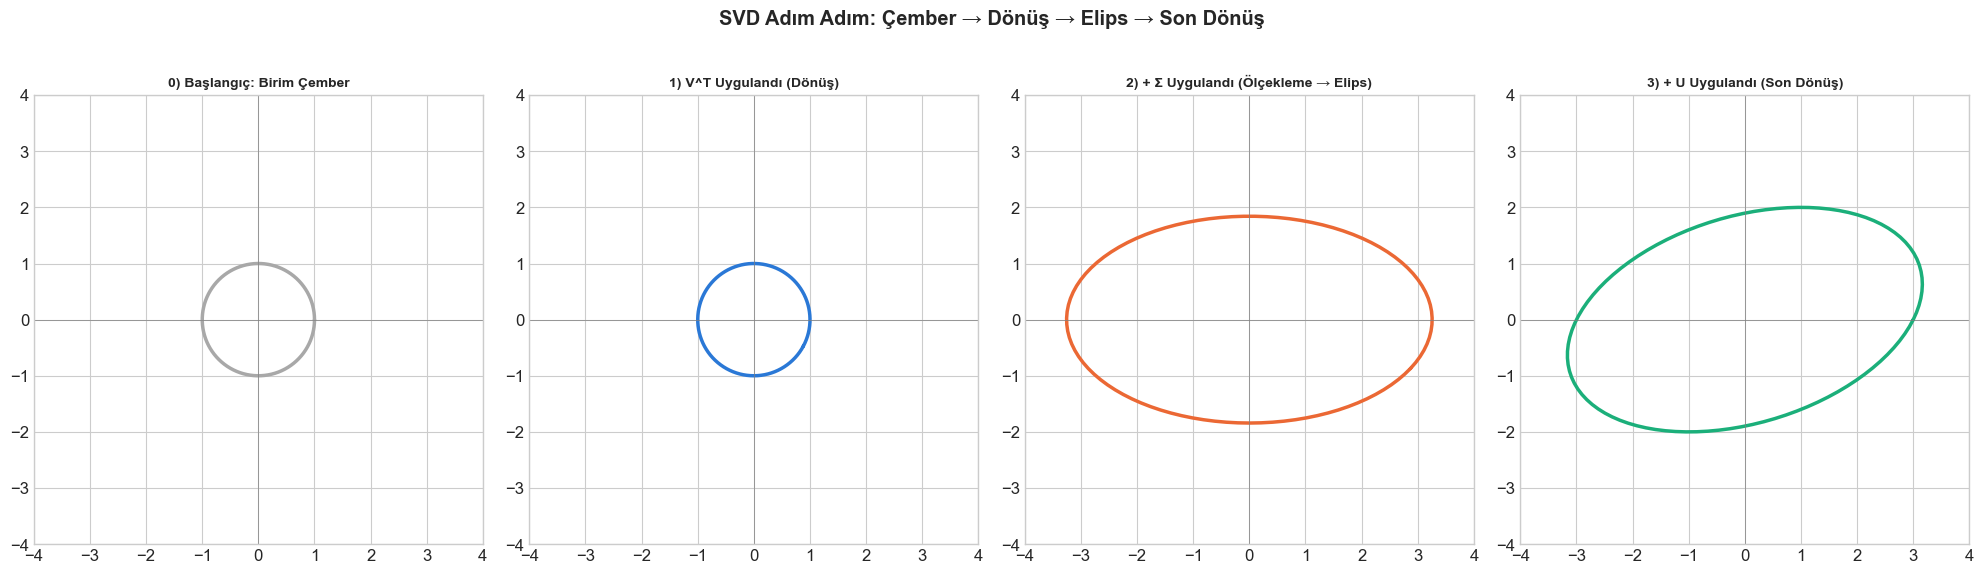


Son adım (adım 3), doğrudan A@çember'e eşit mi? EVET ✓

YORUM: 1. panelde daire hala daire (V^T sadece DÖNDÜRÜYOR, şekli bozmuyor).
2. panelde daire artık bir ELİPS (Σ, eksenleri farklı miktarlarda UZATIYOR - bu
uzunluklar tam olarak tekil değerler). 3. panelde elips son kez döndürülüyor (U).
Son şekil, A'yı DOĞRUDAN uygulasaydık çıkacak sonuçla BİREBİR AYNI - SVD gerçekten
A'yı 3 basit adıma ayırabiliyor.


In [91]:
# Kare olmayan/simetrik-olmayan bir matris secelim (02'deki gibi ozel bir simetrik ornek DEGIL,
# SVD'nin GENEL guclu tarafini gormek icin)
A = np.array([[3, 1], [0, 2]])

U, tekil_degerler, Vt = np.linalg.svd(A)
Sigma = np.diag(tekil_degerler)

print(f"A = \n{A}")
print(f"\nU (son dönüş) = \n{np.round(U, 4)}")
print(f"\nTekil değerler (Σ'nın köşegeni) = {np.round(tekil_degerler, 4)}")
print(f"\nV^T (ilk dönüş) = \n{np.round(Vt, 4)}")

# Bir birim cember olusturalim (100 nokta)
aci = np.linspace(0, 2*np.pi, 100) 
cember = np.array([np.cos(aci), np.sin(aci)])  # 2 x 100

# ADIM ADIM UYGULAMA:
adim0 = cember                         # baslangic: birim cember
adim1 = Vt @ adim0                     # 1) V^T ile "ilk donus"
adim2 = Sigma @ adim1                  # 2) Sigma ile "olcekleme" (cemberi elipse cevirir)
adim3 = U @ adim2                      # 3) U ile "son donus"

# KARSILASTIRMA: dogrudan A ile donusturursek ne olur?
dogrudan_A = A @ cember

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
basliklar = ['0) Başlangıç: Birim Çember',
             '1) V^T Uygulandı (Dönüş)',
             '2) + Σ Uygulandı (Ölçekleme → Elips)',
             '3) + U Uygulandı (Son Dönüş)']
adimlar = [adim0, adim1, adim2, adim3]
renkler = ['#a8a8a8', '#2a78d6', '#eb6834', '#1baf7a']

for ax, veri, baslik, renk in zip(axes, adimlar, basliklar, renkler):
    ax.plot(veri[0], veri[1], color=renk, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.set_title(baslik, fontsize=10, fontweight='bold')

plt.suptitle('SVD Adım Adım: Çember → Dönüş → Elips → Son Dönüş', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"\nSon adım (adım 3), doğrudan A@çember'e eşit mi? "
      f"{'EVET ✓' if np.allclose(adim3, dogrudan_A) else 'HAYIR'}")

print("\nYORUM: 1. panelde daire hala daire (V^T sadece DÖNDÜRÜYOR, şekli bozmuyor).")
print("2. panelde daire artık bir ELİPS (Σ, eksenleri farklı miktarlarda UZATIYOR - bu")
print("uzunluklar tam olarak tekil değerler). 3. panelde elips son kez döndürülüyor (U).")
print("Son şekil, A'yı DOĞRUDAN uygulasaydık çıkacak sonuçla BİREBİR AYNI - SVD gerçekten")
print("A'yı 3 basit adıma ayırabiliyor.")

---
### 🔧 Python 2 — PCA'yı Sıfırdan Kurma: HR Verisiyle, Hiç Kütüphane Kullanmadan

**Ne yapıyoruz?**  
Bölüm 4'teki 4 adımı (merkezle → kovaryans → özdeğer/özvektör → projekte et) TEK TEK,
gerçek çalışan verisiyle uyguluyoruz. Sonra `sklearn.decomposition.PCA` ile karşılaştırıp
SONUÇLARIN BİREBİR ÖRTÜŞTÜĞÜNÜ kanıtlıyoruz — böylece "kara kutu" gibi kullandığın
`PCA()` fonksiyonunun içinde TAM OLARAK ne olduğunu görmüş olacaksın.

Veri: 1470 çalışan, 35 sütun
PCA için kullanılacak: 1470 satır, 23 sayısal özellik

ADIM 1 tamamlandı: Her sütunun yeni ortalaması ~0 mı? EVET ✓
ADIM 2 tamamlandı: Kovaryans matrisi boyutu = (23, 23)
ADIM 3 tamamlandı: İlk 3 özdeğer = [50710722.6 22117267.5   162638. ]
ADIM 4 tamamlandı: Veri artık 2 boyutlu (23'den 2'ye indirgendi)

Elle bulduğumuz PC1'in standart sapması: 7118.7236
sklearn'in bulduğu PC1'in standart sapması: 7118.7236
Örtüşüyor mü? EVET ✓


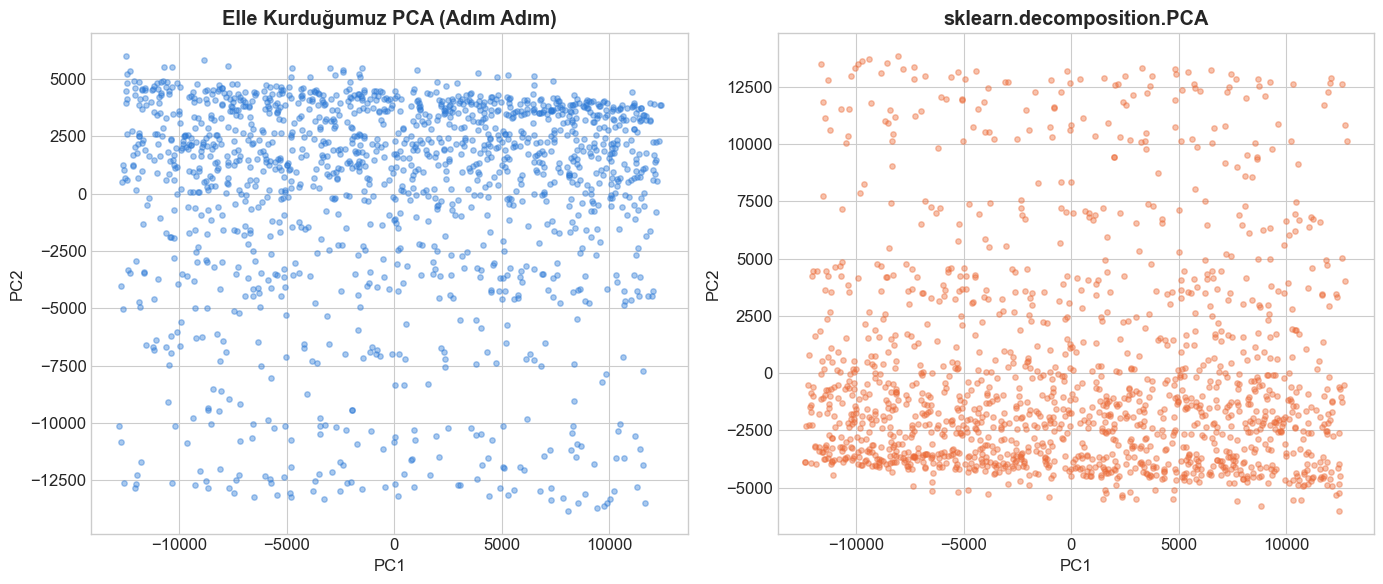


YORUM: İki grafik neredeyse AYNA GÖRÜNTÜSÜ gibi (eksenlerden biri ters dönmüş
olabilir, bu matematiksel olarak ÖNEMSİZ - PCA'da işaret keyfidir). Şekil BİREBİR
aynı - sklearn'ün 'kara kutusu', tam olarak bizim elle yaptığımız 4 adımı yapıyor.


In [92]:
hr = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Veri: {hr.shape[0]} çalışan, {hr.shape[1]} sütun")

# Sadece sayisal sutunlari alalim, anlamli olmayanlari (hep ayni deger olanlar) cikaralim
sayisal_sutunlar = hr.select_dtypes(include='number').columns.tolist()
for gereksiz in ['EmployeeCount', 'EmployeeNumber', 'StandardHours']:
    if gereksiz in sayisal_sutunlar:
        sayisal_sutunlar.remove(gereksiz)

X = hr[sayisal_sutunlar].values.astype(float)
print(f"PCA için kullanılacak: {X.shape[0]} satır, {X.shape[1]} sayısal özellik")

# ============ ADIM 1: MERKEZLE ============
X_ortalama = X.mean(axis=0)
X_merkezli = X - X_ortalama
print(f"\nADIM 1 tamamlandı: Her sütunun yeni ortalaması ~0 mı? "
      f"{'EVET ✓' if np.allclose(X_merkezli.mean(axis=0), 0) else 'HAYIR'}")

# ============ ADIM 2: KOVARYANS MATRISI ============
kovaryans = np.cov(X_merkezli, rowvar=False)  # rowvar=False: sutunlar degisken, satirlar gozlem
print(f"ADIM 2 tamamlandı: Kovaryans matrisi boyutu = {kovaryans.shape}")

# ============ ADIM 3: OZDEGER / OZVEKTOR ============
ozdegerler, ozvektorler = np.linalg.eigh(kovaryans)  # eigh: simetrik matris icin (02 Bolum 5)
sira = np.argsort(ozdegerler)[::-1]  # buyukten kucuge sirala
ozdegerler = ozdegerler[sira]
ozvektorler = ozvektorler[:, sira]
print(f"ADIM 3 tamamlandı: İlk 3 özdeğer = {np.round(ozdegerler[:3], 1)}")

# ============ ADIM 4: PROJEKTE ET (ilk 2 bilesene) ============
ilk_2_bilesen = ozvektorler[:, :2]
X_pca_elle = X_merkezli @ ilk_2_bilesen
print(f"ADIM 4 tamamlandı: Veri artık {X_pca_elle.shape[1]} boyutlu ({X.shape[1]}'den 2'ye indirgendi)")

# ============ KARSILASTIRMA: sklearn PCA ============
from sklearn.decomposition import PCA
pca_sklearn = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_merkezli)

# Not: PCA bilesenlerinin ISARETI (+/-) rastgele cikabilir (matematiksel olarak esdeger,
# yon ayni ama pozitif/negatif olabilir) - karsilastirirken mutlak deger uzerinden bakalim
elle_ilk_bilesen_std = X_pca_elle[:, 0].std()
sklearn_ilk_bilesen_std = X_pca_sklearn[:, 0].std()
print(f"\nElle bulduğumuz PC1'in standart sapması: {elle_ilk_bilesen_std:.4f}")
print(f"sklearn'in bulduğu PC1'in standart sapması: {sklearn_ilk_bilesen_std:.4f}")
print(f"Örtüşüyor mü? {'EVET ✓' if np.isclose(elle_ilk_bilesen_std, sklearn_ilk_bilesen_std) else 'HAYIR'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca_elle[:, 0], X_pca_elle[:, 1], alpha=0.4, color='#2a78d6', s=15)
axes[0].set_title('Elle Kurduğumuz PCA (Adım Adım)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], alpha=0.4, color='#eb6834', s=15)
axes[1].set_title('sklearn.decomposition.PCA', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

print("\nYORUM: İki grafik neredeyse AYNA GÖRÜNTÜSÜ gibi (eksenlerden biri ters dönmüş")
print("olabilir, bu matematiksel olarak ÖNEMSİZ - PCA'da işaret keyfidir). Şekil BİREBİR")
print("aynı - sklearn'ün 'kara kutusu', tam olarak bizim elle yaptığımız 4 adımı yapıyor.")

---
### 📊 Python 3 — Tekil Değerlerin "Enerji" Dağılımı: Scree Plot

**Ne yapıyoruz?**  
Bölüm 6'da anlattığımız fikri gerçek veride görüyoruz: HR verisinin 23 bileşeninin
her birinin ne kadar "önemli" (varyans açıklıyor) olduğunu sıralı bir grafikte gösteriyoruz.
Buna **"scree plot"** deniyor — adı, dağ eteklerindeki taş yığınlarının (scree) şekline
benzemesinden geliyor: başta dik, sonra yavaşça düzleşen bir eğri.

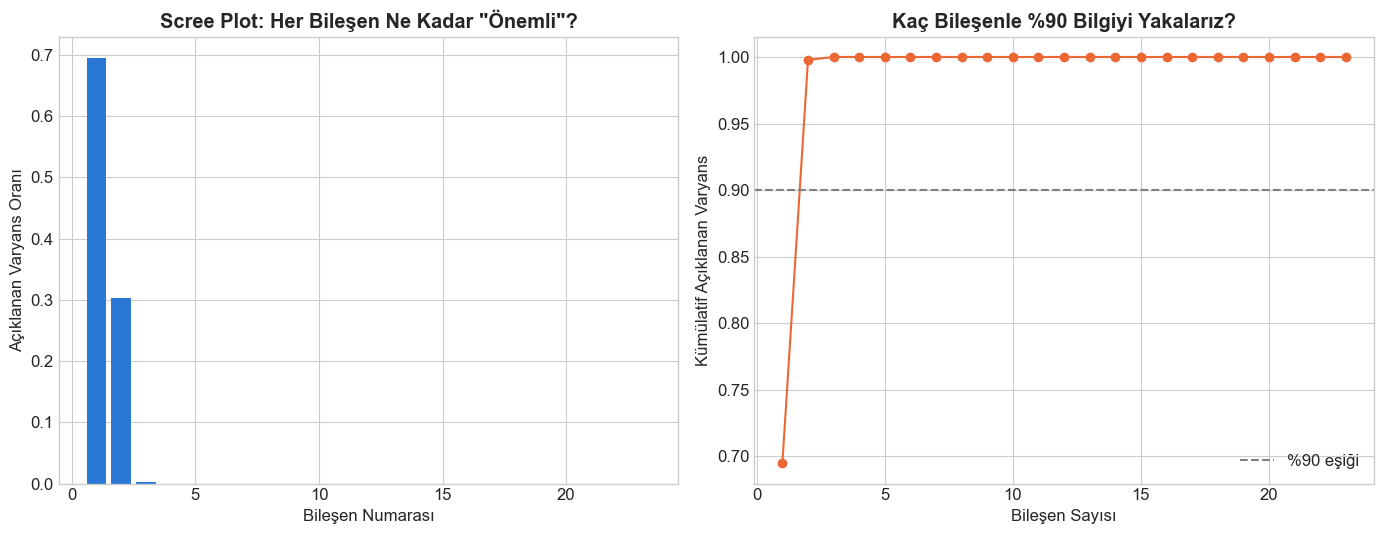

İlk 2 bileşen, toplam varyansın %99.8'ini açıklıyor.
%90 bilgiyi yakalamak için gereken bileşen sayısı: 2 (23 yerine!)

YORUM: İlk bileşen TEK BAŞINA muhtemelen çok büyük bir pay alıyor - bunun sebebi
HR verisindeki bazı sütunların (MonthlyIncome gibi) çok büyük SAYISAL ölçekte olması
(binlerce), diğerlerinin (Education gibi) 1-5 arası olması. Bu, gerçek PCA uygulamalarında
VERİYİ ÖNCE STANDARTLAŞTIRMAN gerektiğinin (ölçek farklarını dengelemek için) önemli bir dersi.


In [93]:
aciklanan_varyans_orani = ozdegerler / ozdegerler.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(range(1, len(ozdegerler)+1), aciklanan_varyans_orani, color='#2a78d6')
axes[0].set_xlabel('Bileşen Numarası')
axes[0].set_ylabel('Açıklanan Varyans Oranı')
axes[0].set_title('Scree Plot: Her Bileşen Ne Kadar "Önemli"?', fontweight='bold')

kumulatif = np.cumsum(aciklanan_varyans_orani)
axes[1].plot(range(1, len(kumulatif)+1), kumulatif, 'o-', color='#eb6834')
axes[1].axhline(0.90, color='gray', linestyle='--', label='%90 eşiği')
axes[1].set_xlabel('Bileşen Sayısı')
axes[1].set_ylabel('Kümülatif Açıklanan Varyans')
axes[1].set_title('Kaç Bileşenle %90 Bilgiyi Yakalarız?', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

ilk_iki_bilesen_orani = aciklanan_varyans_orani[:2].sum()
print(f"İlk 2 bileşen, toplam varyansın %{ilk_iki_bilesen_orani*100:.1f}'ini açıklıyor.")

n_bilesen_90 = np.argmax(kumulatif >= 0.90) + 1
print(f"%90 bilgiyi yakalamak için gereken bileşen sayısı: {n_bilesen_90} (23 yerine!)")

print("\nYORUM: İlk bileşen TEK BAŞINA muhtemelen çok büyük bir pay alıyor - bunun sebebi")
print("HR verisindeki bazı sütunların (MonthlyIncome gibi) çok büyük SAYISAL ölçekte olması")
print("(binlerce), diğerlerinin (Education gibi) 1-5 arası olması. Bu, gerçek PCA uygulamalarında")
print("VERİYİ ÖNCE STANDARTLAŞTIRMAN gerektiğinin (ölçek farklarını dengelemek için) önemli bir dersi.")

---
### ⚠️ Python 3.5 — Bonus: Standartlaştırmanın Şart Olduğunu Kanıtlayalım

**Az önce ne oldu?** İlk bileşen tek başına toplam varyansın neredeyse tamamını
"açıklıyormuş" gibi göründü — ama bu GERÇEK bir bilgi kazancı değil, sadece
`MonthlyIncome` (binlerce) ile `Education` (1-5) arasındaki SAYISAL ÖLÇEK farkının
PCA'yı yanılttığının kanıtı. Şimdi veriyi standartlaştırıp (her sütunu kendi standart
sapmasına bölerek) AYNI analizi tekrarlayacağız — sonucun ne kadar DEĞİŞTİĞİNİ göreceksin.

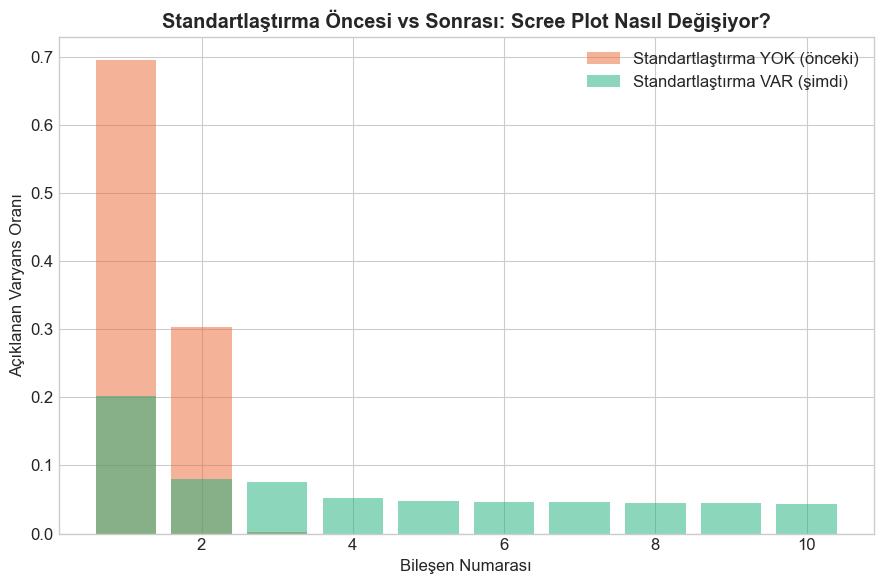

Standartlaştırma YOKKEN %90 bilgi için gereken bileşen: 2
Standartlaştırma VARKEN %90 bilgi için gereken bileşen: 16
İlk bileşenin açıkladığı oran - önce: %69.5, sonra: %20.2

YORUM: Standartlaştırma sonrası bilgi çok daha DENGELİ dağılıyor - artık %90'ı
yakalamak için daha fazla bileşene ihtiyaç var, ama bu daha DÜRÜST bir sonuç -
önceki 'ilk 2 bileşen her şeyi açıklıyor' izlenimi bir YANILSAMAYDI (sadece
MonthlyIncome'un büyük sayılarından kaynaklanıyordu). KURAL: PCA'dan önce HER ZAMAN
StandardScaler kullan, aksi halde büyük ölçekli sütunlar analizi ele geçirir.


In [94]:
from sklearn.preprocessing import StandardScaler

# Veriyi standartlastir: her sutunu kendi standart sapmasina bol (ortalama zaten 0'da)
scaler = StandardScaler()
X_standart = scaler.fit_transform(X)  # bu islem hem merkezliyor hem olcekliyor

kovaryans_standart = np.cov(X_standart, rowvar=False)
ozdegerler_standart, ozvektorler_standart = np.linalg.eigh(kovaryans_standart)
# ONEMLI: ozdegerleri sirlarken OZVEKTORLERI DE AYNI SIRAYLA eslestirmemiz gerekiyor,
# yoksa hangi ozvektorun hangi ozdegere ait oldugu bilgisini kaybederiz.
sira_standart = np.argsort(ozdegerler_standart)[::-1]
ozdegerler_standart = ozdegerler_standart[sira_standart]
ozvektorler_standart = ozvektorler_standart[:, sira_standart]

aciklanan_standart = ozdegerler_standart / ozdegerler_standart.sum()
kumulatif_standart = np.cumsum(aciklanan_standart)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(range(1, 11), aciklanan_varyans_orani[:10], alpha=0.5, color='#eb6834', label='Standartlaştırma YOK (önceki)')
ax.bar(range(1, 11), aciklanan_standart[:10], alpha=0.5, color='#1baf7a', label='Standartlaştırma VAR (şimdi)')
ax.set_xlabel('Bileşen Numarası')
ax.set_ylabel('Açıklanan Varyans Oranı')
ax.set_title('Standartlaştırma Öncesi vs Sonrası: Scree Plot Nasıl Değişiyor?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

n_bilesen_90_standart = np.argmax(kumulatif_standart >= 0.90) + 1
print(f"Standartlaştırma YOKKEN %90 bilgi için gereken bileşen: {n_bilesen_90}")
print(f"Standartlaştırma VARKEN %90 bilgi için gereken bileşen: {n_bilesen_90_standart}")
print(f"İlk bileşenin açıkladığı oran - önce: %{aciklanan_varyans_orani[0]*100:.1f}, "
      f"sonra: %{aciklanan_standart[0]*100:.1f}")

print("\nYORUM: Standartlaştırma sonrası bilgi çok daha DENGELİ dağılıyor - artık %90'ı")
print("yakalamak için daha fazla bileşene ihtiyaç var, ama bu daha DÜRÜST bir sonuç -")
print("önceki 'ilk 2 bileşen her şeyi açıklıyor' izlenimi bir YANILSAMAYDI (sadece")
print("MonthlyIncome'un büyük sayılarından kaynaklanıyordu). KURAL: PCA'dan önce HER ZAMAN")
print("StandardScaler kullan, aksi halde büyük ölçekli sütunlar analizi ele geçirir.")

---
### 🖼️ Python 4 — Görüntü Sıkıştırma: SVD'nin En Görsel Uygulaması

**Ne yapıyoruz?**  
Bölüm 7'deki fikri uyguluyoruz: gerçek bir fotoğrafın SVD'sini alıp, farklı sayıda ($k$)
tekil değer kullanarak "sıkıştırılmış" versiyonlarını yan yana göreceğiz. $k$ arttıkça
görüntünün nasıl netleştiğini izle.

Görüntü boyutu: (512, 512) (yani 512x512 = 262,144 piksel)
Toplam tekil değer sayısı: 512


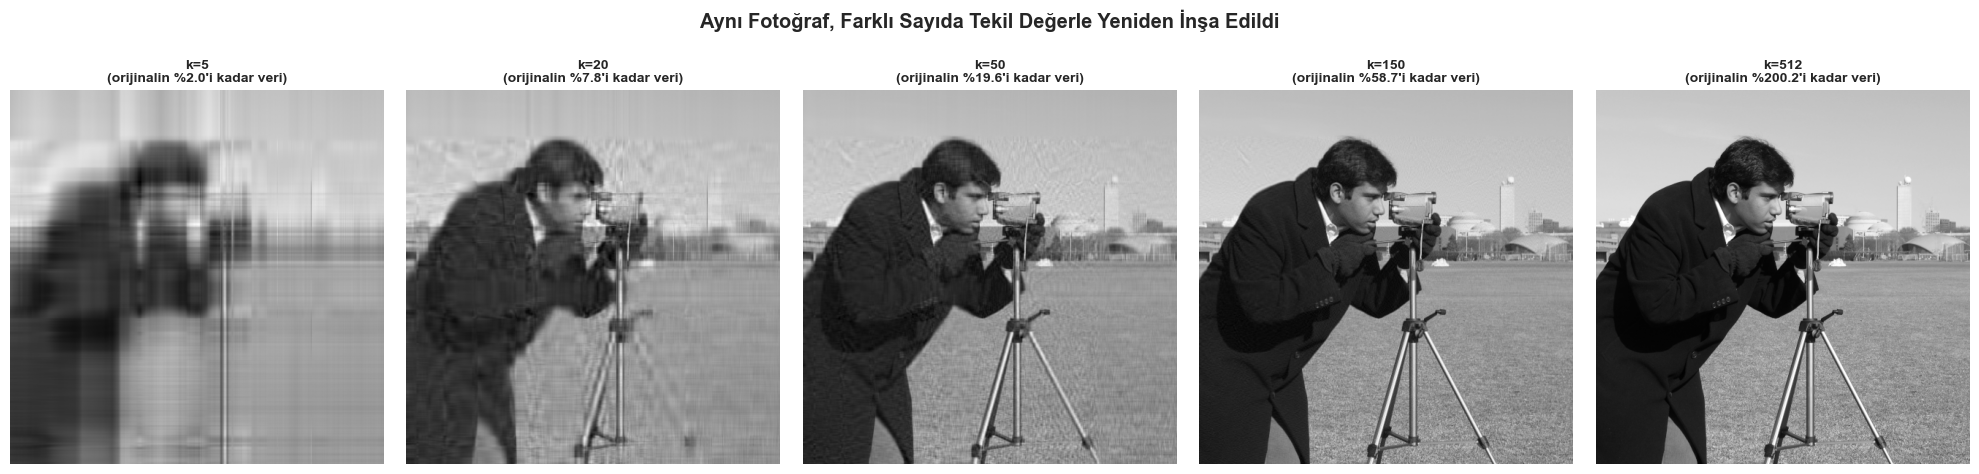


YORUM: k=5'te fotoğraf bulanık ama ANA HATLARI (kişinin silueti, arka plan)
hala görülebiliyor - bu, ilk birkaç tekil değerin 'en önemli/kaba' bilgiyi taşıdığını
kanıtlıyor. k=150'de fotoğraf orijinalle neredeyse ayırt edilemez ama SADECE orijinal
verinin küçük bir kısmı kadar yer kaplıyor - bu tam olarak JPEG gibi formatların
kullandığı 'kayıplı sıkıştırma' mantığının basitleştirilmiş bir versiyonu.


In [95]:
from skimage import data

goruntu = data.camera().astype(float)  # 512x512 siyah-beyaz fotograf, yerlesik (indirme gerekmez)
print(f"Görüntü boyutu: {goruntu.shape} (yani {goruntu.shape[0]}x{goruntu.shape[1]} = "
      f"{goruntu.shape[0]*goruntu.shape[1]:,} piksel)")

U_img, S_img, Vt_img = np.linalg.svd(goruntu, full_matrices=False)
print(f"Toplam tekil değer sayısı: {len(S_img)}")

k_degerleri = [5, 20, 50, 150, 512]

fig, axes = plt.subplots(1, len(k_degerleri), figsize=(20, 4.5))
for ax, k in zip(axes, k_degerleri):
    # Sadece ilk k tekil degeri kullanarak goruntuyu YENIDEN INSA et
    sikistirilmis = U_img[:, :k] @ np.diag(S_img[:k]) @ Vt_img[:k, :]
    ax.imshow(sikistirilmis, cmap='gray')
    orjinal_boyut = goruntu.shape[0] * goruntu.shape[1]
    sikistirilmis_boyut = k * (goruntu.shape[0] + goruntu.shape[1] + 1)
    oran = sikistirilmis_boyut / orjinal_boyut
    ax.set_title(f'k={k}\n(orijinalin %{oran*100:.1f}\'i kadar veri)', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Aynı Fotoğraf, Farklı Sayıda Tekil Değerle Yeniden İnşa Edildi', fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nYORUM: k=5'te fotoğraf bulanık ama ANA HATLARI (kişinin silueti, arka plan)")
print("hala görülebiliyor - bu, ilk birkaç tekil değerin 'en önemli/kaba' bilgiyi taşıdığını")
print("kanıtlıyor. k=150'de fotoğraf orijinalle neredeyse ayırt edilemez ama SADECE orijinal")
print("verinin küçük bir kısmı kadar yer kaplıyor - bu tam olarak JPEG gibi formatların")
print("kullandığı 'kayıplı sıkıştırma' mantığının basitleştirilmiş bir versiyonu.")

---
### 👥 Python 5 — Gerçek Veride PCA: Attrition'ı (İşten Ayrılma) 2D'de Görselleştirme

**Ne yapıyoruz?**  
Standartlaştırılmış veriyi 2 boyuta indirip, **işten ayrılan (Attrition=Yes)** ve
**ayrılmayan (Attrition=No)** çalışanları farklı renklerle işaretleyeceğiz. Soru: 23
boyutlu bir bilgiyi sadece 2 boyuta sıkıştırdığımızda, bu iki grup hala GÖRSEL olarak
ayrışıyor mu?

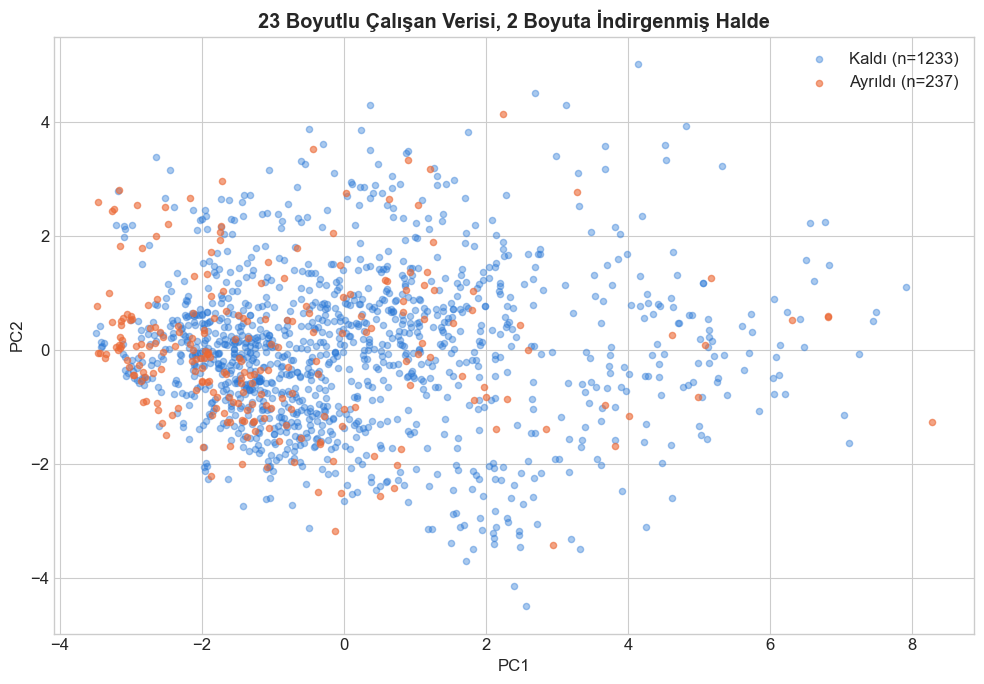

YORUM: Turuncu (ayrılanlar) ve mavi (kalanlar) noktalar TAM AYRIŞMIYOR (PCA
denetimsiz/unsupervised bir yöntem - Attrition bilgisini HİÇ kullanmadan sadece
genel veri yapısına bakarak 2 boyuta indirdik) ama turuncu noktaların belirli
bölgelerde daha YOĞUN olduğunu görebiliyorsan, bu 23 boyutlu verideki BAZI örüntülerin
2 boyutta bile kısmen görünür kaldığının işareti - PCA'nın gücü tam olarak bu.


In [96]:
# ozvektorler_standart artik py-standardized hucresinde DOGRU sekilde sirali
# (ozdegerler_standart ile eslesecek sekilde) - dogrudan kullanabiliriz.
X_pca_standart_2d = X_standart @ ozvektorler_standart[:, :2]

ayrildi_maskesi = (hr['Attrition'] == 'Yes').values

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca_standart_2d[~ayrildi_maskesi, 0], X_pca_standart_2d[~ayrildi_maskesi, 1],
           alpha=0.4, s=20, color='#2a78d6', label=f'Kaldı (n={(~ayrildi_maskesi).sum()})')
ax.scatter(X_pca_standart_2d[ayrildi_maskesi, 0], X_pca_standart_2d[ayrildi_maskesi, 1],
           alpha=0.6, s=20, color='#eb6834', label=f'Ayrıldı (n={ayrildi_maskesi.sum()})')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('23 Boyutlu Çalışan Verisi, 2 Boyuta İndirgenmiş Halde', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Turuncu (ayrılanlar) ve mavi (kalanlar) noktalar TAM AYRIŞMIYOR (PCA")
print("denetimsiz/unsupervised bir yöntem - Attrition bilgisini HİÇ kullanmadan sadece")
print("genel veri yapısına bakarak 2 boyuta indirdik) ama turuncu noktaların belirli")
print("bölgelerde daha YOĞUN olduğunu görebiliyorsan, bu 23 boyutlu verideki BAZI örüntülerin")
print("2 boyutta bile kısmen görünür kaldığının işareti - PCA'nın gücü tam olarak bu.")

---
### 🎯 Python 6 — Kaç Bileşen Yeterli? Kümülatif Açıklanan Varyans (Standartlaştırılmış)

**Ne yapıyoruz?**  
Python 3.5'teki standartlaştırılmış veriyle, "%80 ve %95 bilgiyi korumak için kaç bileşen
gerekiyor" sorusuna kesin bir sayıyla cevap veriyoruz — gerçek bir projede PCA kullanırken
soracağın en pratik soru bu.

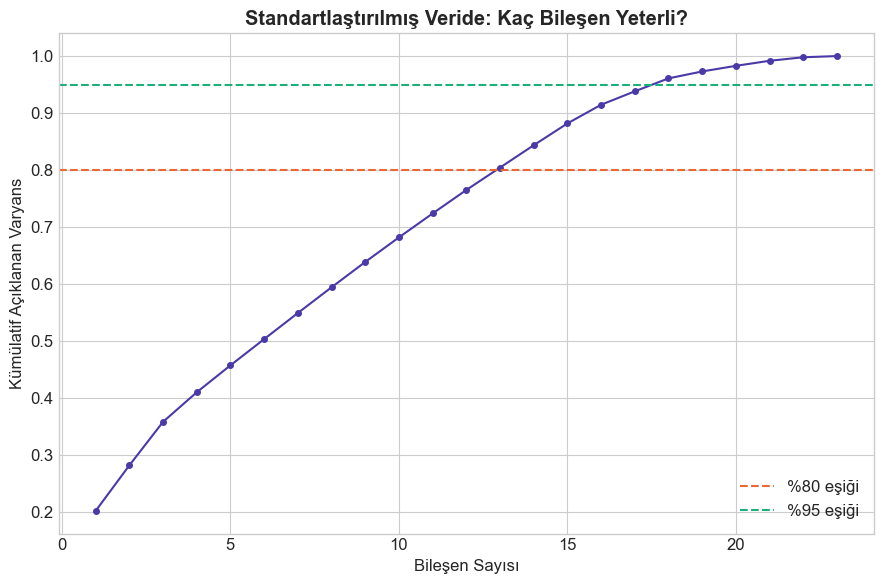

%80 bilgi için gereken bileşen sayısı: 13 (orijinal 23 yerine)
%95 bilgi için gereken bileşen sayısı: 18 (orijinal 23 yerine)

YORUM: 23 boyutlu veriyi 13 boyuta indirerek bilginin %80'ini
koruyabiliyorsun - bu, hem görselleştirme hem de makine öğrenmesi modellerini
hızlandırmak (daha az özellik = daha hızlı eğitim) için pratikte kullanılan gerçek bir teknik.


In [97]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, len(kumulatif_standart)+1), kumulatif_standart, 'o-', color='#4a3aa7', markersize=4)
ax.axhline(0.80, color='#eb6834', linestyle='--', label='%80 eşiği')
ax.axhline(0.95, color='#1baf7a', linestyle='--', label='%95 eşiği')
ax.set_xlabel('Bileşen Sayısı')
ax.set_ylabel('Kümülatif Açıklanan Varyans')
ax.set_title('Standartlaştırılmış Veride: Kaç Bileşen Yeterli?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

n_80 = np.argmax(kumulatif_standart >= 0.80) + 1
n_95 = np.argmax(kumulatif_standart >= 0.95) + 1
print(f"%80 bilgi için gereken bileşen sayısı: {n_80} (orijinal {X.shape[1]} yerine)")
print(f"%95 bilgi için gereken bileşen sayısı: {n_95} (orijinal {X.shape[1]} yerine)")

print(f"\nYORUM: {X.shape[1]} boyutlu veriyi {n_80} boyuta indirerek bilginin %80'ini")
print("koruyabiliyorsun - bu, hem görselleştirme hem de makine öğrenmesi modellerini")
print("hızlandırmak (daha az özellik = daha hızlı eğitim) için pratikte kullanılan gerçek bir teknik.")

---
## ✏️ Egzersizler

---

### **E1.** 
Python 1'deki SVD görsel demosunu farklı bir $2\times 2$ matrisle (kendi
seçtiğin sayılarla, ama simetrik OLMAYAN bir matris seç) tekrarla — çemberin nasıl bir
elipse dönüştüğünü gözlemle.


==== Egzersiz 1: SVD ile Görsel Demosu ====
Tekil değerler (Σ'nın köşegeni) = [9.0446 0.4423]


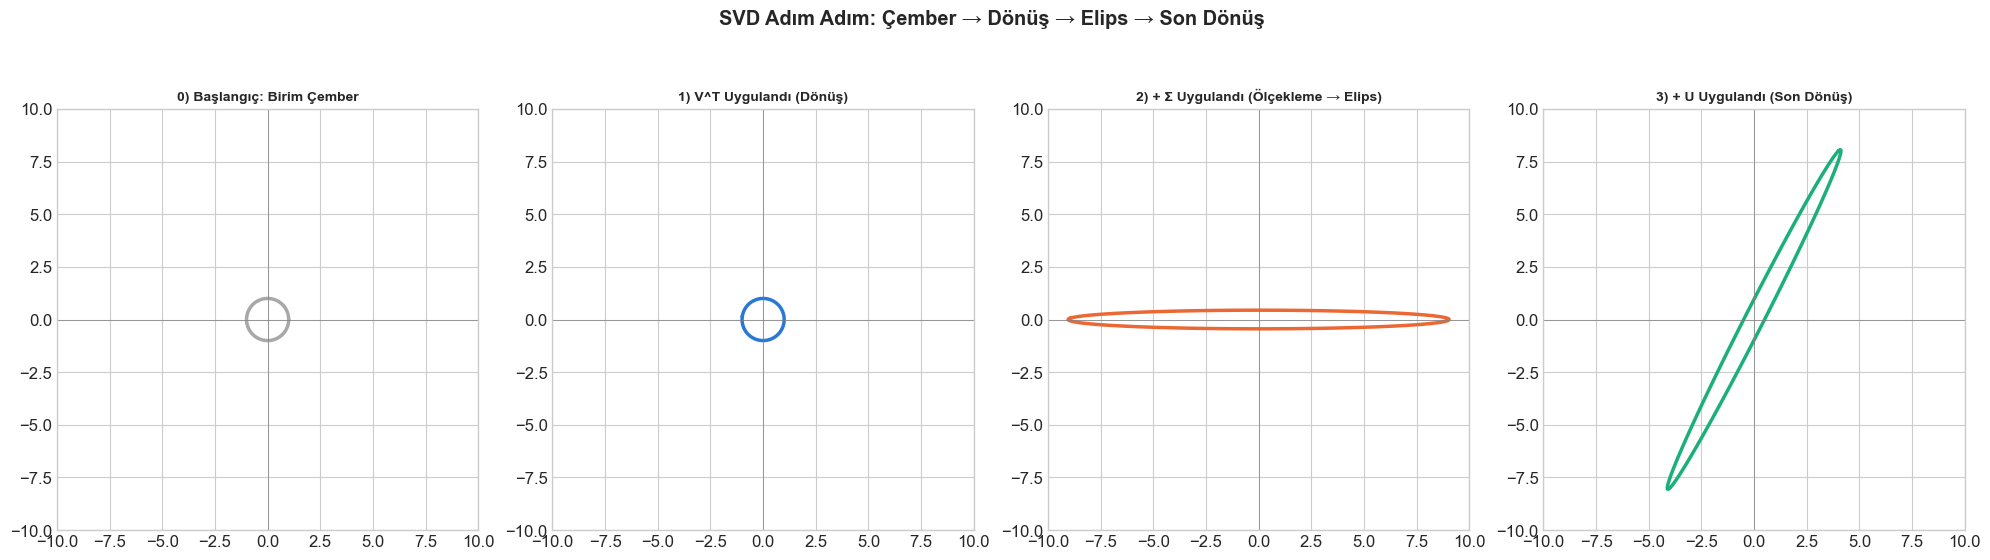

In [98]:
print("\n==== Egzersiz 1: SVD ile Görsel Demosu ====")
A = np.array([[4, 1], [8, 1]])

U, tekil_degerler, Vt = np.linalg.svd(A)
Sigma = np.diag(tekil_degerler) 

print(f"Tekil değerler (Σ'nın köşegeni) = {np.round(tekil_degerler, 4)}")

aci = np.linspace(0, 2*np.pi, 100)
cember = np.array([np.cos(aci), np.sin(aci)])  # 2 x 100

adim0 = cember                         # baslangic: birim cember
adim1 = Vt @ adim0                     # 1) V^T ile "ilk donus"
adim2 = Sigma @ adim1                  # 2) Sigma ile "olcekleme" (cemberi elipse cevirir)
adim3 = U @ adim2                      # 3) U ile "son donus"

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
basliklar = ['0) Başlangıç: Birim Çember',
             '1) V^T Uygulandı (Dönüş)',
             '2) + Σ Uygulandı (Ölçekleme → Elips)',
             '3) + U Uygulandı (Son Dönüş)']
adimlar = [adim0, adim1, adim2, adim3]
renkler = ['#a8a8a8', '#2a78d6', '#eb6834', '#1baf7a']

for ax, veri, baslik, renk in zip(axes, adimlar, basliklar, renkler):
    ax.plot(veri[0], veri[1], color=renk, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.5); ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
    ax.set_aspect('equal')
    ax.set_title(baslik, fontsize=10, fontweight='bold')

plt.suptitle('SVD Adım Adım: Çember → Dönüş → Elips → Son Dönüş', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---

### **E2.**
Python 2'deki "elle PCA" kodunu, `sklearn`'ün `PCA` sınıfı yerine doğrudan
`np.linalg.svd()` kullanarak tekrarla (Bölüm 4'ün sonundaki "SVD ile kısayol" notunu
uygula). Sonuçların yine birebir örtüştüğünü doğrula.


 ==== Egzersiz 2: SVD ile Boyut İndirgeme ====
Veri: 1470 çalışan, 35 sütun
SVD için kullanılacak: 1470 satır, 23 sayısal özellik
SVD ile elde edilen ilk 3 özdeğer: [50710722.5818 22117267.5435   162637.9531]
Projeksiyon sonrası PC1'in standart sapması: 7118.7236
Projeksiyon sonrası PC1'in standart sapması: 7118.7236


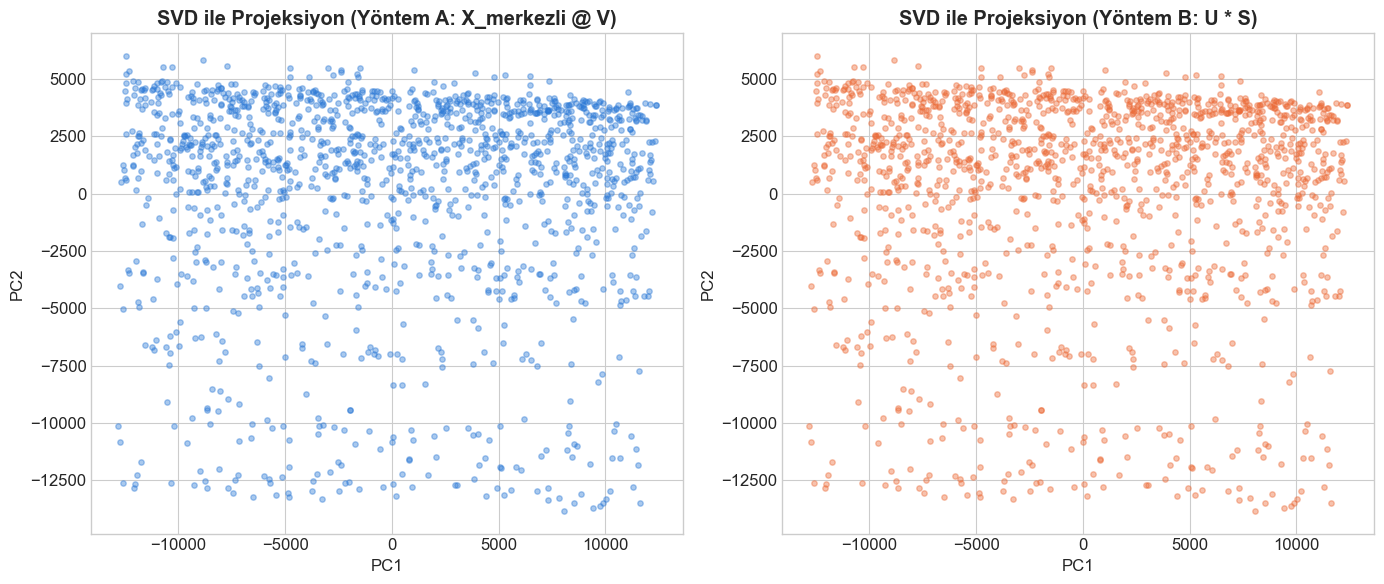

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n ==== Egzersiz 2: SVD ile Boyut İndirgeme ====")

hr = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Veri: {hr.shape[0]} çalışan, {hr.shape[1]} sütun")

# Sadece sayısal sütunları alalım
sayisal_sutunlar = hr.select_dtypes(include='number').columns.tolist()
for gereksiz in ['EmployeeCount', 'EmployeeNumber', 'StandardHours']:
    if gereksiz in sayisal_sutunlar:
        sayisal_sutunlar.remove(gereksiz)

X = hr[sayisal_sutunlar].values.astype(float)
print(f"SVD için kullanılacak: {X.shape[0]} satır, {X.shape[1]} sayısal özellik")

# ============ DÜZELTME 1: MERKEZLEME VE ÖRNEK SAYISI ============
X_ortalama = X.mean(axis=0)
X_merkezli = X - X_ortalama  # SVD merkezlenmiş matrisle çalışmalı
n_ornek = X_merkezli.shape[0] # Örnek sayısı satır sayısıdır (X.shape[0])

# SVD'ye merkezlenmiş TÜM VERİYİ gönderiyoruz
U, S, Vt = np.linalg.svd(X_merkezli, full_matrices=False)

ozvektorler = Vt.T # SVD ile elde edilen özvektörler (Vt'nin transpozu)
ozdegerler = (S ** 2) / (n_ornek - 1)  # Kovaryans matrisinin özdeğerleri

print(f"SVD ile elde edilen ilk 3 özdeğer: {np.round(ozdegerler[:3], 4)}")

ilk_2_bilesen_svd = ozvektorler[:, :2]

# ============ DÜZELTME 2: YÖNTEM A (Matris Çarpımı) ============
# Tüm veriyi (X_merkezli) ilk 2 bileşene projekte ediyoruz
X_pca_svd_A = X_merkezli @ ilk_2_bilesen_svd

svd_A_ilk_bilesen_std = X_pca_svd_A[:, 0].std()
print(f"Projeksiyon sonrası PC1'in standart sapması: {svd_A_ilk_bilesen_std:.4f}")

# ============ DÜZELTME 3: YÖNTEM B (Doğrudan U ve S ile) ============
# U'nun ilk 2 sütununu, S'in ilk iki değeriyle skaler olarak çarpıyoruz
X_pca_svd_B = U[:, :2] * S[:2] 

svd_B_ilk_bilesen_std = X_pca_svd_B[:, 0].std()
print(f"Projeksiyon sonrası PC1'in standart sapması: {svd_B_ilk_bilesen_std:.4f}")

# Grafik Çizimi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_pca_svd_A[:, 0], X_pca_svd_A[:, 1], alpha=0.4, color='#2a78d6', s=15)
axes[0].set_title('SVD ile Projeksiyon (Yöntem A: X_merkezli @ V)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca_svd_B[:, 0], X_pca_svd_B[:, 1], alpha=0.4, color='#eb6834', s=15)
axes[1].set_title('SVD ile Projeksiyon (Yöntem B: U * S)', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()


---

### **E3.**
Python 4'teki görüntü sıkıştırma demosunu `skimage.data.astronaut()` (renkli bir
görüntü) ile tekrarla — renkli görüntülerde SVD'yi her renk kanalına (R, G, B) AYRI AYRI
uygulaman gerektiğine dikkat et.


 ==== Egzersiz 3: Renkli Görüntü Sıkıştırma ====
Görüntü boyutu: (512, 512, 3) (yani 512x512 = 262,144 piksel, 3 renk kanalı)


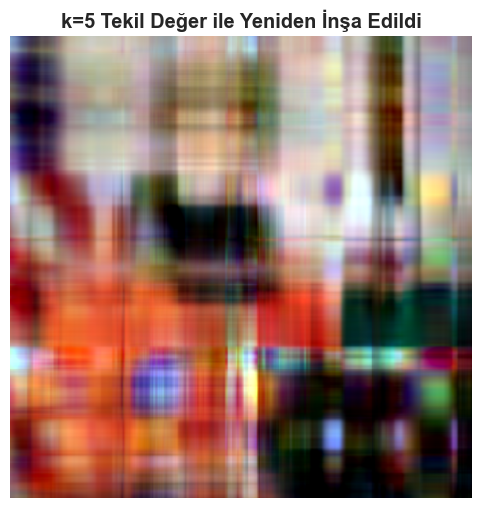

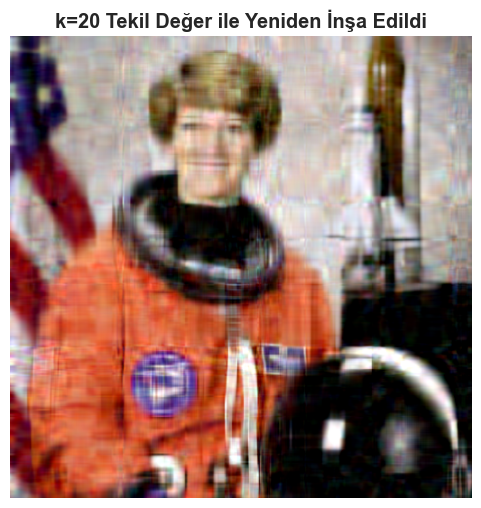

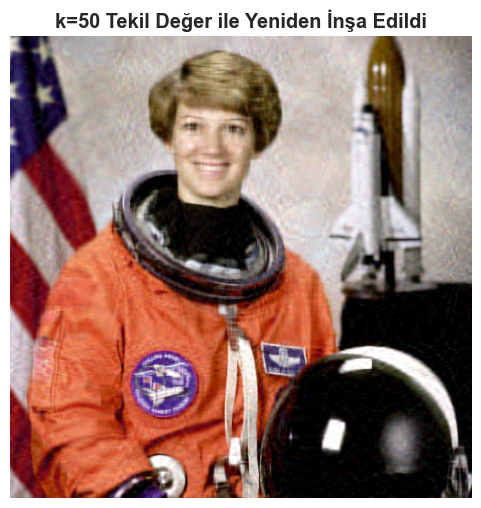

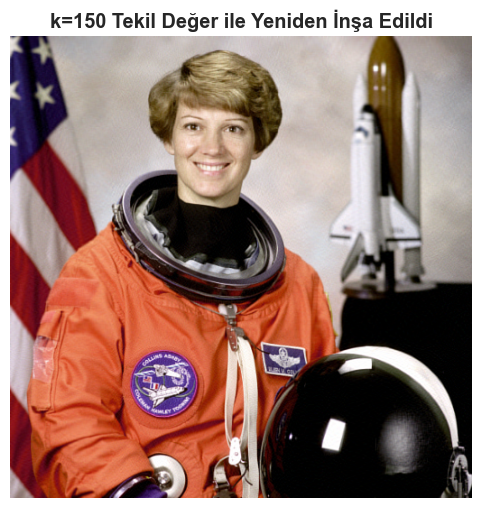

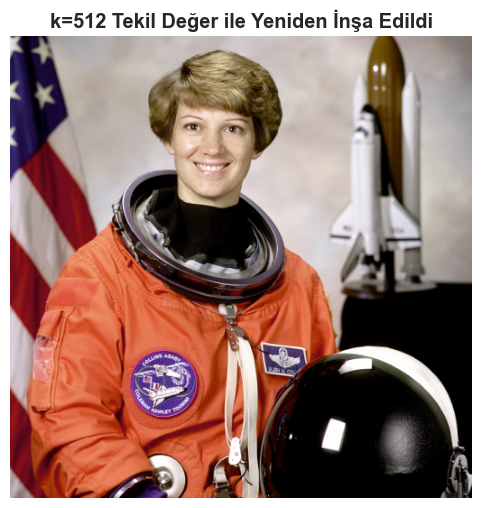

In [100]:
print("\n ==== Egzersiz 3: Renkli Görüntü Sıkıştırma ====")

from skimage import data

astronot = data.astronaut().astype(float)  # 512x512x3 renkli fotoğraf, yerleşik (indirme gerekmez)
print(f"Görüntü boyutu: {astronot.shape} (yani {astronot.shape[0]}x{astronot.shape[1]} = {astronot.shape[0]*astronot.shape[1]:,} piksel, 3 renk kanalı)")

U_r, S_r, Vt_r = np.linalg.svd(astronot[:, :, 0], full_matrices=False)  # Kırmızı kanal
U_g, S_g, Vt_g = np.linalg.svd(astronot[:, :, 1], full_matrices=False)  # Yeşil kanal
U_b, S_b, Vt_b = np.linalg.svd(astronot[:, :, 2], full_matrices=False)  # Mavi kanal

k_degerleri = [5, 20, 50, 150, 512]

for k in k_degerleri:
    # Her kanal için ilk k tekil değeri kullanarak yeniden inşa et
    R_k = U_r[:, :k] @ np.diag(S_r[:k]) @ Vt_r[:k, :]
    G_k = U_g[:, :k] @ np.diag(S_g[:k]) @ Vt_g[:k, :]
    B_k = U_b[:, :k] @ np.diag(S_b[:k]) @ Vt_b[:k, :]
    
    # Renkli görüntüyü birleştir
    astronot_k = np.stack((R_k, G_k, B_k), axis=2)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(np.clip(astronot_k / 255.0, 0, 1))  # Normalize et ve sınırla
    plt.title(f'k={k} Tekil Değer ile Yeniden İnşa Edildi', fontweight='bold')
    plt.axis('off')
    plt.show()

---

### **E4.**
HR verisinde `MonthlyIncome`'u PCA'ya hiç dahil etmeden (çıkararak) Python 3.5'teki
analizi tekrarla — scree plot'un şekli nasıl değişiyor? Bu, "tek bir aşırı-ölçekli sütunun"
etkisini somut olarak gösteriyor mu?


 ==== Egzersiz 4: MonthlyIncome'sız PCA ====
Veri: 1470 çalışan, 35 sütun


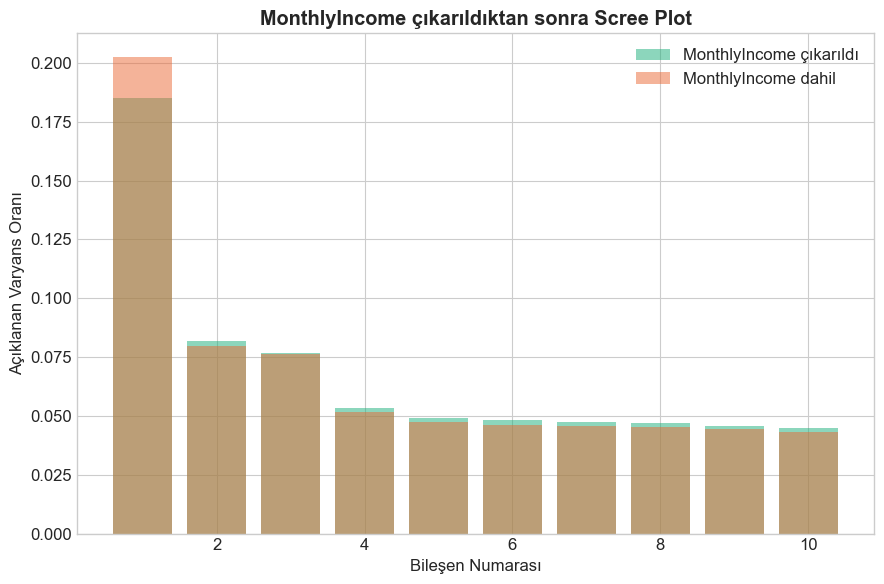

In [109]:
print("\n ==== Egzersiz 4: MonthlyIncome'sız PCA ====")

hr = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Veri: {hr.shape[0]} çalışan, {hr.shape[1]} sütun")

# Sadece sayısal sütunları alalım
sayisal_sutunlar = hr.select_dtypes(include='number').columns.tolist()
for gereksiz in ['EmployeeCount', 'EmployeeNumber', 'StandardHours']:
    if gereksiz in sayisal_sutunlar:
        sayisal_sutunlar.remove(gereksiz)

monthlyincome_dahil = sayisal_sutunlar.copy()
monthlyincome_yok = sayisal_sutunlar.copy()
if 'MonthlyIncome' in monthlyincome_yok:
    monthlyincome_yok.remove('MonthlyIncome')

scaler = StandardScaler()

X_standart_yok = scaler.fit_transform(hr[monthlyincome_yok].values.astype(float))
X_standart_dahil = scaler.fit_transform(hr[monthlyincome_dahil].values.astype(float))


kovaryans_standart_yok = np.cov(X_standart_yok, rowvar=False)
kovaryans_standart_dahil = np.cov(X_standart_dahil, rowvar=False)

ozdegerler_standart_yok, ozvektorler_standart_yok = np.linalg.eigh(kovaryans_standart_yok)
ozdegerler_standart_dahil, ozvektorler_standart_dahil = np.linalg.eigh(kovaryans_standart_dahil)

sira_standart_yok = np.argsort(ozdegerler_standart_yok)[::-1]
ozdegerler_standart_yok = ozdegerler_standart_yok[sira_standart_yok]
ozvektorler_standart_yok = ozvektorler_standart_yok[:, sira_standart_yok]

sira_standart_dahil = np.argsort(ozdegerler_standart_dahil)[::-1]
ozdegerler_standart_dahil = ozdegerler_standart_dahil[sira_standart_dahil]
ozvektorler_standart_dahil = ozvektorler_standart_dahil[:, sira_standart_dahil]

aciklanan_standart_yok = ozdegerler_standart_yok / ozdegerler_standart_yok.sum()
kumulatif_standart_yok = np.cumsum(aciklanan_standart_yok)

aciklanan_standart_dahil = ozdegerler_standart_dahil / ozdegerler_standart_dahil.sum()
kumulatif_standart_dahil = np.cumsum(aciklanan_standart_dahil)

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(range(1, 11), aciklanan_standart_yok[:10], alpha=0.5, color='#1baf7a', label='MonthlyIncome çıkarıldı')
ax.bar(range(1, 11), aciklanan_standart_dahil[:10], alpha=0.5, color='#eb6834', label='MonthlyIncome dahil')
ax.set_xlabel('Bileşen Numarası')
ax.set_ylabel('Açıklanan Varyans Oranı')
ax.set_title('MonthlyIncome çıkarıldıktan sonra Scree Plot', fontweight='bold')
plt.tight_layout()
plt.legend()
plt.show()

---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [3Blue1Brown — Essence of Linear Algebra](https://www.3blue1brown.com/topics/linear-algebra) | — | Genel sezgi için |
| [setosa.io — PCA](https://setosa.io/ev/principal-component-analysis/) | — | PCA'nın en net interaktif anlatımı |
| [StatQuest — PCA](https://www.youtube.com/watch?v=FgakZw6K1QQ) | Video | Çok net, adım adım görsel anlatım |
| [Mathematics for Machine Learning](https://mml-book.github.io) | Ch. 10 | PCA'nın matematiksel detayı |
| [scikit-learn PCA Dokümantasyonu](https://scikit-learn.org/stable/modules/decomposition.html#pca) | Kütüphane | Bu notebook'ta karşılaştırdığımız araç |
| [IBM HR Analytics Employee Attrition](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) | Veri | HR verisinin kaynağı |